In [1]:
import pandas as pd
from ift6758.data import SeasonData
from ift6758.data.data_cleaning import clean_season_data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
############################## Question 4 #1 ##############################

In [2]:
## First, we get the data from season 2022-2023, clean it and save it to a dataframe
season2022Data = SeasonData(2022)
season2022Data.get_data_from_api()
df = clean_season_data(season2022Data)

df.head(10)

,game_id,period,period_time,team,event_type,x_coord,y_coord,shooter,goalie,shot_type,empty_net,strength,season,game_type
0,2022020001,1,00:23,28,Shot,44.0,8.0,Player_8478414,Goalie_8477424,wrist,False,Even,2022,Regular
1,2022020001,1,00:59,18,Shot,33.0,-8.0,Player_8475218,Goalie_8473503,slap,False,Even,2022,Regular
2,2022020001,1,01:01,18,Goal,74.0,5.0,Player_8480748,Goalie_8473503,wrist,False,Even,2022,Regular
3,2022020001,1,01:12,18,Shot,81.0,-15.0,Player_8476925,Goalie_8473503,wrist,False,Even,2022,Regular
4,2022020001,1,02:42,28,Shot,72.0,2.0,Player_8478904,Goalie_8477424,tip-in,False,Even,2022,Regular
5,2022020001,1,04:09,18,Shot,40.0,-22.0,Player_8479371,Goalie_8473503,snap,False,Even,2022,Regular
6,2022020001,1,04:19,28,Shot,49.0,12.0,Player_8478067,Goalie_8477424,wrist,False,Even,2022,Regular
7,2022020001,1,04:44,28,Shot,46.0,18.0,Player_8478099,Goalie_8477424,slap,False,Even,2022,Regular
8,2022020001,1,05:45,18,Shot,40.0,-13.0,Player_8475168,Goalie_8473503,wrist,False,Even,2022,Regular
9,2022020001,1,06:23,18,Shot,71.0,-21.0,Player_8480009,Goalie_8473503,wrist,False,Even,2022,Regular


In [3]:
total_shots_df = df.groupby("shot_type")["event_type"].count()
goals_df = df[df["event_type"] == "Goal"].groupby("shot_type")["event_type"].count()

shots_df = pd.DataFrame({"total_shots": total_shots_df, "goals": goals_df}).fillna(0)

print(shots_df)

              total_shots  goals
shot_type                       
Unknown                22     22
backhand             7014    785
bat                   211     54
between-legs           52      8
cradle                  2      1
deflected            1394    236
poke                  422     65
slap                10054    755
snap                14213   1681
tip-in               5726    908
wrap-around           778     61
wrist               48198   4451


[]

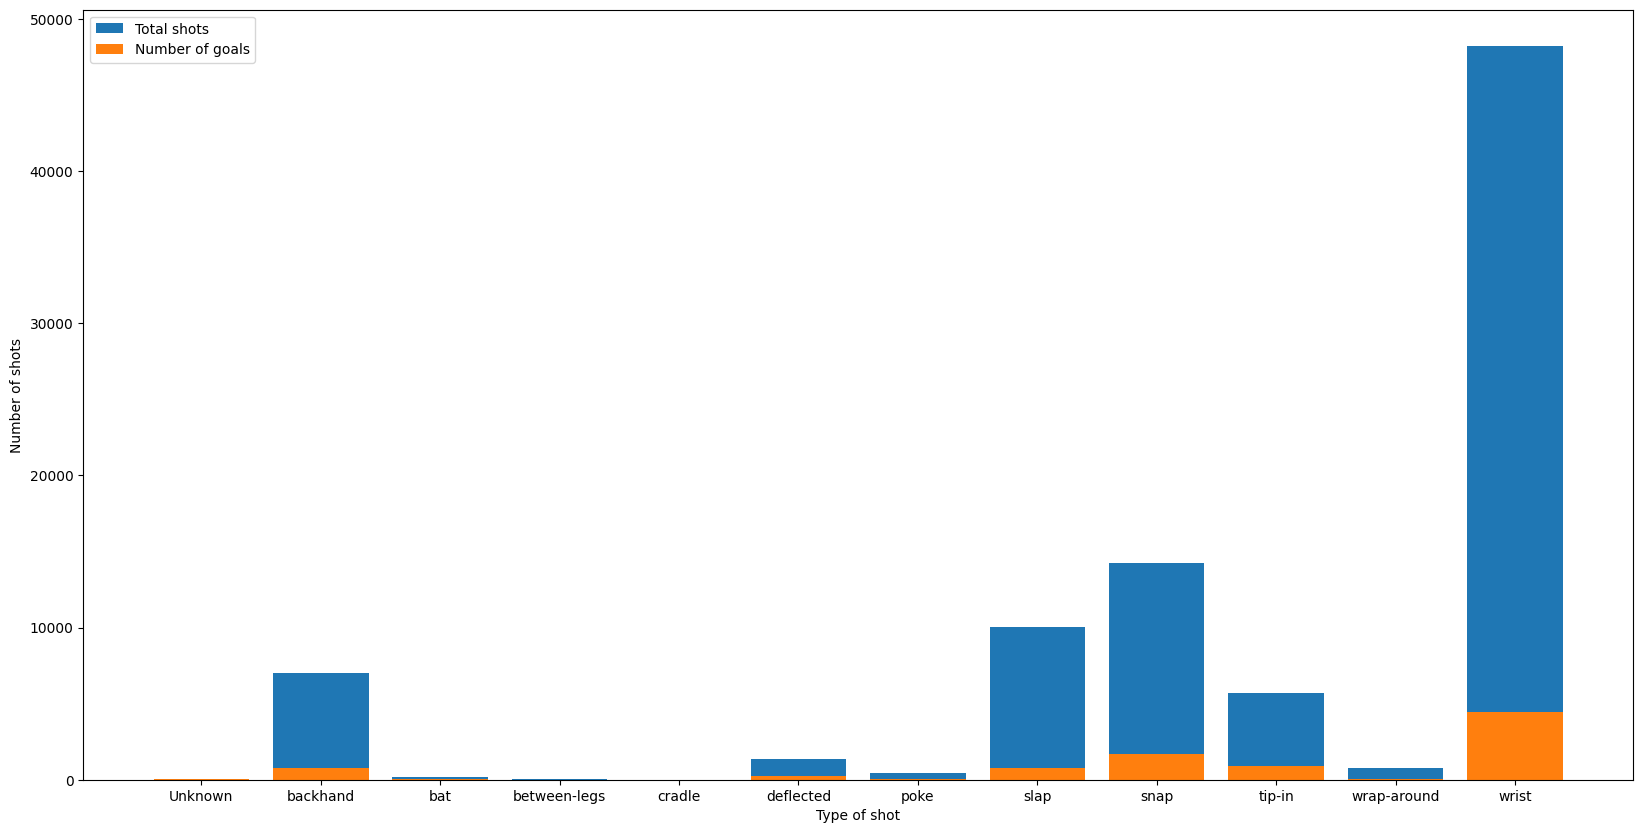

In [4]:
# Maybe modify the plot, it's the best one I found so far

plt.figure(figsize=(20,10))

plt.bar(shots_df.index, shots_df["total_shots"], label="Total shots")
plt.bar(shots_df.index, shots_df["goals"], label="Number of goals")

plt.xlabel("Type of shot")
plt.ylabel("Number of shots")
#plt.yscale("log")
plt.legend()
plt.plot()

In [ ]:
########### a ###########

In [6]:
# First, we get the data from seasons 2018-2019, 2019-2020 and 2020-2021
season2018Data = SeasonData(2018)
season2018Data.get_data_from_api()
df_2018 = clean_season_data(season2018Data)

season2019Data = SeasonData(2019)
season2019Data.get_data_from_api()
df_2019 = clean_season_data(season2019Data)

season2020Data = SeasonData(2020)
season2020Data.get_data_from_api()
df_2020 = clean_season_data(season2020Data)

dfArray = [df_2018, df_2019, df_2020]

In [ ]:
# Now, we compute the distance to the goal for every shot

# Since the coordinates were normalized in the cleaning step, the team will always shoot to the right goal, which is at coordinates x = 89, y = 0
goal_pos = np.array([89.0, 0.0])

for df in dfArray:
    shot_coords = df.apply(lambda x: np.array([x["standardized_x_coord"], x["standardized_y_coord"]]), axis=1)

    # Compute the euclidean distance between the position of the shot and the position of the goal for each shot
    distance_to_goal = shot_coords.apply(lambda x: np.linalg.norm(x - goal_pos))

    df["distance_from_goal"] = distance_to_goal

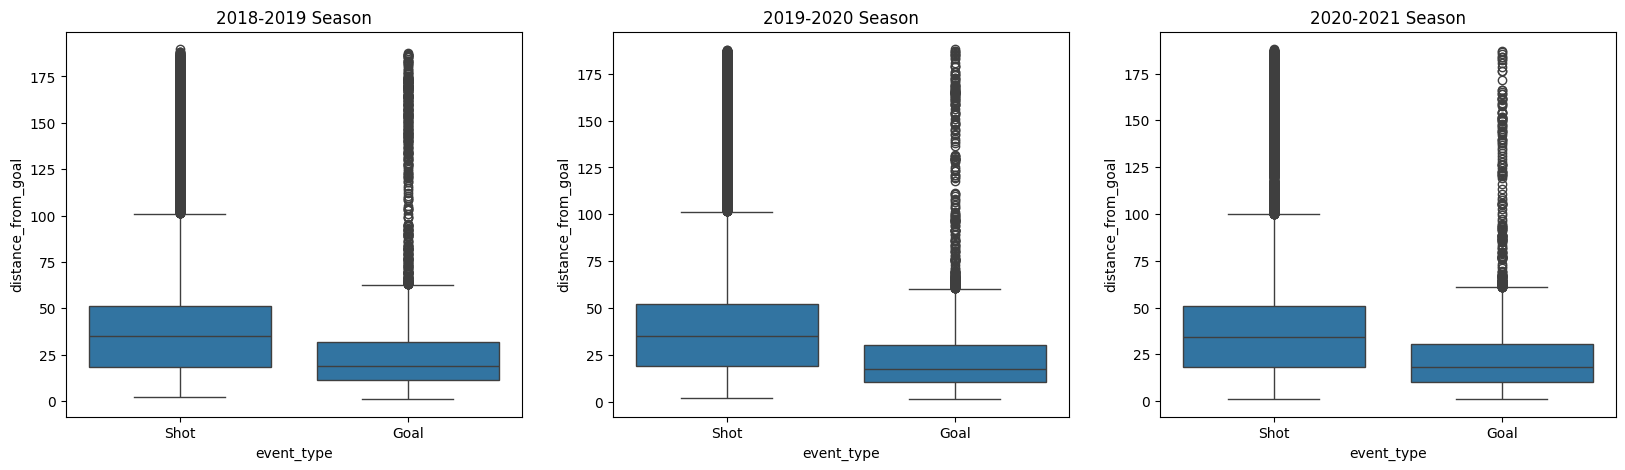

In [8]:
# Now, we plot the points for each of the seasons according to the distance to the goal
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Plotting the 2018-2019 season
sns.boxplot(x="event_type", y="distance_from_goal", data=df_2018, ax=ax[0])
ax[0].set_title("2018-2019 Season")

# Plotting the 2019-2020 season
sns.boxplot(x="event_type", y="distance_from_goal", data=df_2019, ax=ax[1])
ax[1].set_title("2019-2020 Season")
ax[1].invert_xaxis()

# Plotting the 2020-2021 season
sns.boxplot(x="event_type", y="distance_from_goal", data=df_2020, ax=ax[2])
ax[2].set_title("2020-2021 Season")

plt.show()